# LSTM for ETF Cross-Asset Momentum

The LSTM tests whether temporal gating improves on the linear baseline for
21-day ETF return prediction. It processes each ETF's feature history as a
sequence, providing a direct test of whether learned temporal state adds value
beyond the engineered lookback features.

**Learning Objectives**:
- Read the LSTM walk-forward checkpoints from the results registry
- Tune the checkpoint (epoch count) on validation, holdout sealed, under a
  full-coverage guard that excludes fold-collapsed checkpoints
- Determine whether temporal gating captures signal beyond linear lookback features
- Place the LSTM against the Ridge and GBM baselines on the same cross-section

**Book Reference**: Chapter 13, Section 13.8 (Case Study Results)

**Prerequisites**: [`06_linear`](06_linear.ipynb), [`07_gbm`](07_gbm.ipynb) (comparison baselines)

In [1]:
"""LSTM - ETF deep learning with registered walk-forward checkpoints."""

import sqlite3
import warnings

import numpy as np
import plotly.graph_objects as go
import polars as pl
import torch
import yaml
from IPython.display import Markdown, display

from case_studies.utils.analytics import load_best_ic_per_family
from case_studies.utils.deep_learning import (
    _resolve_arch_name,
    create_model,
    run_dl_cv,
)
from case_studies.utils.latent_factors.case_study import _training_input_identity
from case_studies.utils.registry import (
    build_training_spec,
    load_prediction_metrics,
    load_prediction_sets,
    training_hash_from_spec,
    training_run_status,
)
from utils.modeling import load_configs, load_modeling_dataset
from utils.paths import get_case_study_dir
from utils.style import COLORS

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "etfs"
MODEL = "lstm"
PRIMARY_LABEL = ""
MAX_SYMBOLS = 0
FORCE_RETRAIN = False  # Set True to retrain configs that already have complete hashes
PREDICTION_SPLIT = "validation"
N_EPOCHS = 100
LOOKBACK = 60
BATCH_SIZE = 2048
MC_DROPOUT = False
MAX_FOLDS = 0

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

if not PRIMARY_LABEL:
    PRIMARY_LABEL = setup["labels"]["primary"]
    print(f"Label from setup.yaml: {PRIMARY_LABEL}")
else:
    print(f"Label override: {PRIMARY_LABEL}")

dl_config = setup.get("modeling", {}).get("dl", {})
DEVICE = dl_config.get("device", "gpu")

device_str = "cuda" if DEVICE == "gpu" and torch.cuda.is_available() else "cpu"
print(f"Case study: {CASE_STUDY_ID} | Model: {MODEL}")
print(f"Device: {device_str} | Epochs: {N_EPOCHS} | Lookback: {LOOKBACK}")

Label from setup.yaml: fwd_ret_21d
Case study: etfs | Model: lstm
Device: cuda | Epochs: 100 | Lookback: 60


## 1. Load Data

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)
input_data_spec = _training_input_identity(CASE_STUDY_ID, PRIMARY_LABEL)

dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_col = mds.entity_cols[0] if mds.entity_cols else "symbol"
splits = mds.splits
if MAX_FOLDS:
    splits = splits[:MAX_FOLDS]
n_features = len(feature_names)

print(f"Dataset: {len(dataset):,} rows × {n_features} features")
print(f"Label: {label_col} | Entity: {entity_col} | Folds: {len(splits)}")
print(f"Input digest: {input_data_spec['input_digest']}")

dataset_pd = dataset.to_pandas()
n_entities = dataset_pd[entity_col].nunique()
print(f"Entities: {n_entities}")

Dataset: 402,526 rows × 71 features
Label: fwd_ret_21d | Entity: symbol | Folds: 8
Input digest: sha256:8f4cbf103fe6a0aa79dc24309e51e4e9a4396af936f9b3a027472d3aaaddd939
Entities: 99


## 2. Prior Baselines

Load IC results from earlier pipeline stages (Ch11 linear, Ch12 GBM)
rather than re-running them here.

In [5]:
prior_baselines = {}
_baselines = load_best_ic_per_family(["linear", "gbm"], case_studies=[CASE_STUDY_ID])
if not _baselines.is_empty():
    for row in _baselines.iter_rows(named=True):
        # The full-coverage linear leader is a Ridge config; label it plainly so
        # the comparison section (and its `.get("Ridge (Ch11)")`) resolves.
        if row["family"] == "linear":
            prior_baselines["Ridge (Ch11)"] = row["ic_mean"]
        elif row["family"] == "gbm":
            prior_baselines["GBM (Ch12)"] = row["ic_mean"]

if prior_baselines:
    for name, ic in prior_baselines.items():
        print(f"  {name}: IC={ic:+.4f}" if ic is not None else f"  {name}: IC=N/A")
else:
    print("  No prior results found - run 06_linear.py and 07_gbm.py first")

  GBM (Ch12): IC=+0.0746
  Ridge (Ch11): IC=+0.0469


## 3. LSTM

The results registry (`run_log/registry.db`) is the source of truth for this
case study. The single LSTM config (`lstm_h64`) is trained walk-forward
with cross-sectional IC evaluated at epoch checkpoints, and every checkpoint is
stored as a validation prediction set with its IC. Here we read those
checkpoints back from the registry rather than retraining: on a cached checkout
no GPU work happens and the registry is never rewritten. Only a config
with no registered validation predictions triggers a fresh `run_dl_cv` train.

In [6]:
dl_configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, "deep_learning")
dl_configs = [c for c in dl_configs if c["params"].get("architecture") == MODEL]

# Apply Papermill training overrides. N_EPOCHS / BATCH_SIZE / lookback are part of
# the training-spec hash, so they select which registered run to read. Changing
# them selects a different training identity. Keep defaults for the production
# reader; overrides only apply in isolated tests or an explicitly authorized run.
for cfg in dl_configs:
    if cfg.get("n_epochs", 100) != N_EPOCHS:
        cfg["n_epochs"] = N_EPOCHS
    if cfg.get("batch_size", 2048) != BATCH_SIZE:
        cfg["batch_size"] = BATCH_SIZE
    if cfg["params"].get("lookback", 60) != LOOKBACK:
        cfg["params"]["lookback"] = LOOKBACK

print(f"Grid: {len(dl_configs)} config(s) × {len(splits)} folds (checkpoints read from registry)")
for cfg in dl_configs:
    print(
        f"  {cfg['config_name']}: {cfg['params'].get('architecture', '?')} "
        f"({cfg.get('n_epochs', 100)} epochs, lookback {cfg['params'].get('lookback', 60)})"
    )

Grid: 1 config(s) × 8 folds (checkpoints read from registry)
  lstm_h64: lstm (100 epochs, lookback 60)


In [7]:
def _rebuild_from_registry(cfg: dict) -> dict | None:
    """Rebuild one config's checkpoint curve and peak IC from the registry.

    Returns None if the config has no complete registered validation set (a fresh
    reader who deleted the registry), in which case it is queued for training.

    The peak checkpoint is selected under a **checkpoint-level full-coverage
    guard**: a checkpoint whose predictions collapse to near-constant on some
    folds yields no cross-sectional IC on those validation dates, so its
    ``ic_n_days`` falls below the full-coverage maximum and its IC is measured on
    a smaller, non-comparable set of days. We keep the highest-IC checkpoint only
    among full-coverage checkpoints, mirroring the config-level guard in
    ``06_linear`` / ``07_gbm`` / ``13_model_analysis``. (This is stricter than the
    raw ``max(IC)`` a single config would otherwise report.)
    """
    spec = build_training_spec(
        cfg["family"],
        cfg["config_name"],
        label_col,
        n_folds=len(splits),
        n_epochs=cfg.get("n_epochs"),
        extra_params={
            "batch_size": cfg.get("batch_size", BATCH_SIZE),
            "input_data_spec": input_data_spec,
            "lookback": cfg["params"].get("lookback", LOOKBACK),
            "max_train_sequences": 0,
        },
    )
    status = training_run_status(CASE_STUDY_ID, spec)
    t_hash = training_hash_from_spec(spec)
    psets = load_prediction_sets(CASE_STUDY_ID, training_hash=t_hash, split=PREDICTION_SPLIT)
    if not status.complete or psets.is_empty():
        return None

    interval = int(cfg.get("checkpoint_interval", cfg.get("n_epochs", N_EPOCHS)))
    total_epochs = int(cfg.get("n_epochs", N_EPOCHS))
    expected_epochs = list(range(interval, total_epochs + 1, interval))
    if not expected_epochs or expected_epochs[-1] != total_epochs:
        expected_epochs.append(total_epochs)
    actual_epochs = sorted(int(value) for value in psets["checkpoint_value"].to_list())
    if actual_epochs != expected_epochs:
        return None

    curve = []
    with sqlite3.connect(CASE_DIR / "run_log" / "registry.db") as connection:
        for row in psets.iter_rows(named=True):
            prediction_hash = row["prediction_hash"]
            prediction_path = (
                CASE_DIR / "run_log" / "predictions" / prediction_hash / "predictions.parquet"
            )
            fold_count = connection.execute(
                "SELECT COUNT(*) FROM fold_metrics WHERE prediction_hash = ?",
                (prediction_hash,),
            ).fetchone()[0]
            m = load_prediction_metrics(CASE_STUDY_ID, prediction_hash=prediction_hash)
            if m.is_empty() or not prediction_path.exists() or fold_count != len(splits):
                return None
            nd = m["ic_n_days"][0]
            daily_ic = m["ic_mean_daily"][0]
            if nd is None or daily_ic is None:
                return None
            curve.append(
                {
                    "config": cfg["config_name"],
                    "epoch": int(row["checkpoint_value"]),
                    "ic_mean": float(daily_ic),
                    "ic_n_days": float(nd),
                    "prediction_hash": prediction_hash,
                }
            )
    curve.sort(key=lambda c: c["epoch"])

    _finite = [c["ic_n_days"] for c in curve if np.isfinite(c["ic_n_days"])]
    full_days = max(_finite) if _finite else None
    full_cps = [
        c for c in curve if np.isfinite(c["ic_n_days"]) and c["ic_n_days"] == full_days
    ] or curve
    partial_epochs = [c["epoch"] for c in curve if c not in full_cps]
    peak = max(full_cps, key=lambda c: c["ic_mean"])
    return {
        "config_name": cfg["config_name"],
        "best_epoch": peak["epoch"],
        "best_ic": peak["ic_mean"],
        "ic_n_days": peak["ic_n_days"],
        "best_prediction_hash": peak["prediction_hash"],
        "curve": curve,
        "full_days": full_days,
        "partial_epochs": partial_epochs,
        "cached": True,
    }


grid_results = []
to_train = []
for cfg in dl_configs:
    rebuilt = _rebuild_from_registry(cfg)
    if rebuilt is not None:
        grid_results.append(rebuilt)
        _pe = rebuilt["partial_epochs"]
        _note = f"  (partial ckpts excluded: {_pe})" if _pe else ""
        print(
            f"  {rebuilt['config_name']:10s}  full-cov best epoch={rebuilt['best_epoch']:3d}  "
            f"IC={rebuilt['best_ic']:+.4f}  n_days={int(rebuilt['ic_n_days'])}  (cached){_note}"
        )
    else:
        to_train.append(cfg)

# Uncached configs train via run_dl_cv, which writes the registry. On a cached
# checkout `to_train` is empty, so run_dl_cv is never called, no GPU work runs,
# and the registry stays byte-identical.
if to_train:
    print(f"\nTraining {len(to_train)} uncached config(s)...")
    run_dl_cv(
        dataset_pd,
        splits,
        feature_names=feature_names,
        label_col=label_col,
        date_col=date_col,
        entity_col=entity_col,
        configs=to_train,
        n_features=n_features,
        device=device_str,
        save_dir=CASE_DIR / "run_log" / "training" / "deep_learning",
        register=True,
        force_retrain=FORCE_RETRAIN,
        prediction_split=PREDICTION_SPLIT,
        case_study=CASE_STUDY_ID,
        notebook="09_dl_lstm",
        temporal_by_fold=mds.temporal_by_fold,
        temporal_keys=mds.temporal_keys,
        temporal_feature_names=mds.temporal_feature_names,
        input_data_spec=input_data_spec,
    )
    for cfg in to_train:
        rebuilt = _rebuild_from_registry(cfg)
        if rebuilt is None:
            raise RuntimeError(
                f"Training completed but registered checkpoints are incomplete for "
                f"{cfg['config_name']}"
            )
        rebuilt["cached"] = False
        grid_results.append(rebuilt)


Training 1 uncached config(s)...


Fold-major CV: 8 folds × 1 configs × 60 lookback

  Fold 0: creating sequences...


    train=221,577 seq across 99 symbols
    val=22,114 seq across 96 symbols
    creating datasets...
    datasets ready
    lstm_h64:


      epoch   1/100: train_loss=0.003259


      epoch   2/100: train_loss=0.001975


...

      epoch 100/100: train_loss=0.000296, val_loss=0.004996, IC=-0.0312


      best_ep=45, IC=-0.0275 (630.9s, 20 checkpoints)


  lstm_h64: best_epoch=70, IC=+0.0199 (7573.8s)


    registered lstm_h64 incrementally (20 per-epoch slices)

  Best: lstm_h64 @ epoch 70 (IC=+0.0199)


  Saved to ~/ml4t/public-s6-etfs/case_studies/etfs/run_log/training/deep_learning


## 4. Grid Results & Full-Coverage Guard

The LSTM's reported IC is its **peak-checkpoint** validation value: the epoch
count is tuned on the validation folds by scanning the checkpoint grid and
keeping the highest-IC checkpoint, the sequence-model analogue of early
stopping. The holdout is never touched here.

A full-coverage guard (mirroring `06_linear`, `07_gbm`, `13_model_analysis`)
excludes any checkpoint whose predictions collapse on some folds: such a
checkpoint scores on fewer validation days (`ic_n_days` below the full-coverage
maximum) and its IC is not comparable to a full-coverage IC. The table below
makes the comparison surface explicit for every run.

In [8]:
grid_results.sort(
    key=lambda r: r["best_ic"] if np.isfinite(r["best_ic"]) else -np.inf, reverse=True
)

_finite_days = [r["ic_n_days"] for r in grid_results if np.isfinite(r.get("ic_n_days", np.nan))]
if _finite_days:
    _full_days = max(_finite_days)
    full_cov = [
        r
        for r in grid_results
        if np.isfinite(r.get("ic_n_days", np.nan)) and r["ic_n_days"] == _full_days
    ]
    partial_cov = [r for r in grid_results if r not in full_cov]
else:
    _full_days = None
    full_cov = grid_results
    partial_cov = []

best = full_cov[0] if full_cov else None
best_name = best["config_name"] if best else None
best_epoch = best["best_epoch"] if best else 0
best_ic = best["best_ic"] if best else float("nan")

# Report the config's per-checkpoint curve so any excluded partial checkpoint is
# visible next to the selected full-coverage winner.
if best:
    print(f"Config: {best_name}   full-coverage validation days = {int(_full_days)}")
    print(f"{'Epoch':>6s} {'IC':>9s} {'N Days':>8s}  Coverage")
    print("-" * 40)
    for c in sorted(best["curve"], key=lambda c: c["epoch"]):
        _full = np.isfinite(c["ic_n_days"]) and c["ic_n_days"] == best["full_days"]
        _mark = " *selected" if c["epoch"] == best_epoch else ""
        _cov = "full" if _full else "PARTIAL (excluded)"
        print(f"{c['epoch']:6d} {c['ic_mean']:+9.4f} {int(c['ic_n_days']):8d}  {_cov}{_mark}")
    print(f"\nFull-coverage winner: {best_name} @ epoch {best_epoch} (IC={best_ic:+.4f})")

Config: lstm_h64   full-coverage validation days = 1995
 Epoch        IC   N Days  Coverage
----------------------------------------
     5   -0.0099     1995  full
    10   -0.0012     1995  full
    15   +0.0063     1995  full
    20   +0.0026     1995  full
    25   -0.0002     1995  full
    30   +0.0066     1995  full
    35   +0.0072     1995  full
    40   +0.0087     1995  full
    45   +0.0123     1995  full
    50   +0.0091     1995  full
    55   +0.0148     1995  full
    60   +0.0174     1995  full
    65   +0.0181     1995  full
    70   +0.0199     1995  full *selected
    75   +0.0188     1995  full
    80   +0.0195     1995  full
    85   +0.0175     1995  full
    90   +0.0189     1995  full
    95   +0.0191     1995  full
   100   +0.0192     1995  full

Full-coverage winner: lstm_h64 @ epoch 70 (IC=+0.0199)


## 5. Learning Curves

Validation IC at each epoch checkpoint. The full-coverage winner is highlighted
in amber; any partial-coverage checkpoint excluded from selection is drawn in
copper. Coverage labels appear only where they identify the selected or an
excluded checkpoint.

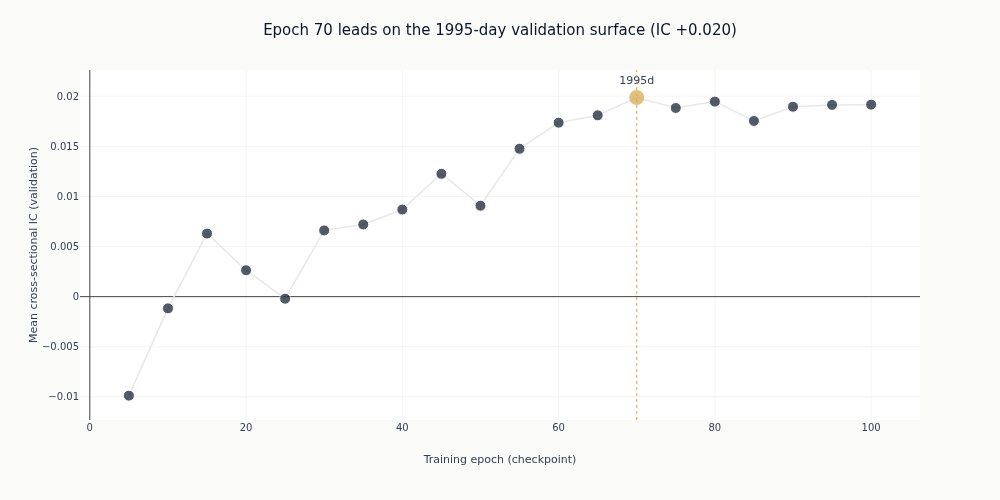

In [9]:
_curve = sorted(best["curve"], key=lambda c: c["epoch"]) if best else []
if _curve:
    _epochs = [c["epoch"] for c in _curve]
    _ics = [c["ic_mean"] for c in _curve]
    _nd = [c["ic_n_days"] for c in _curve]
    _mk_color = [
        COLORS["amber"]
        if c["epoch"] == best_epoch
        else (COLORS["copper"] if c["epoch"] in best["partial_epochs"] else COLORS["blue"])
        for c in _curve
    ]
    _mk_size = [16 if c["epoch"] == best_epoch else 11 for c in _curve]
    fig_lc = go.Figure()
    fig_lc.add_trace(
        go.Scatter(
            x=_epochs,
            y=_ics,
            mode="lines+markers+text",
            line=dict(color=COLORS["silver_muted"], width=1.5),
            marker=dict(color=_mk_color, size=_mk_size, line=dict(color="white", width=1)),
            text=[
                f"{d:.0f}d" if epoch == best_epoch or d < _full_days else ""
                for epoch, d in zip(_epochs, _nd, strict=True)
            ],
            textposition="top center",
            showlegend=False,
        )
    )
    fig_lc.add_vline(
        x=best_epoch,
        line=dict(color=COLORS["amber"], width=1, dash="dot"),
    )
    _partial_note = (
        f"; partial epochs {best['partial_epochs']} excluded" if best["partial_epochs"] else ""
    )
    fig_lc.update_layout(
        title=(
            f"Epoch {best_epoch} leads on the {_full_days:.0f}-day validation surface"
            f" (IC {best_ic:+.3f}){_partial_note}"
        ),
        height=500,
        width=1000,
        margin=dict(t=70),
        title_font=dict(size=15),
    )
    fig_lc.update_xaxes(title_text="Training epoch (checkpoint)")
    fig_lc.update_yaxes(title_text="Mean cross-sectional IC (validation)")
    fig_lc.show()

## 6. Comparison Against the Baselines

The full-coverage LSTM checkpoint against the Ridge (Ch11) and GBM (Ch12)
leaders on the same label and validation split. The LSTM sits below both: on
this cross-section sequential memory does not add IC over a heavily regularized
linear model or a shallow-tree GBM.

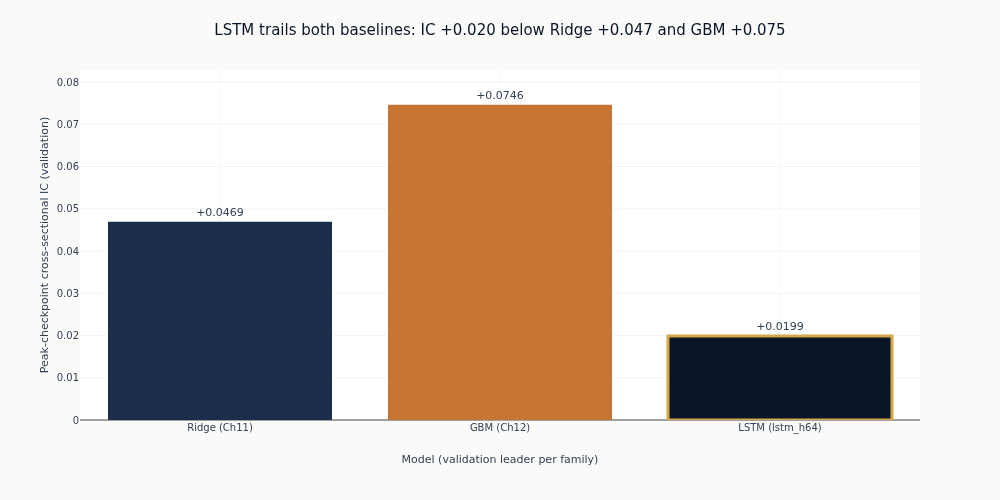

In [10]:
ridge_ic = prior_baselines.get("Ridge (Ch11)", float("nan"))
gbm_ic = prior_baselines.get("GBM (Ch12)", float("nan"))

_labels = ["Ridge (Ch11)", "GBM (Ch12)", f"LSTM ({best_name})"]
_vals = [ridge_ic, gbm_ic, best_ic]
_colors = [COLORS["slate"], COLORS["copper"], COLORS["blue"]]
_line_w = [0, 0, 3]  # outline the LSTM bar to draw the eye
fig_cmp = go.Figure(
    go.Bar(
        x=_labels,
        y=_vals,
        marker=dict(color=_colors, line=dict(color=COLORS["amber"], width=_line_w)),
        text=[f"{v:+.4f}" for v in _vals],
        textposition="outside",
        cliponaxis=False,
        showlegend=False,
    )
)
fig_cmp.update_layout(
    title=(
        f"LSTM trails both baselines: IC {best_ic:+.3f} "
        f"below Ridge {ridge_ic:+.3f} and GBM {gbm_ic:+.3f}"
    ),
    height=500,
    width=1000,
    margin=dict(t=70),
    title_font=dict(size=15),
)
fig_cmp.update_xaxes(title_text="Model (validation leader per family)")
fig_cmp.update_yaxes(title_text="Peak-checkpoint cross-sectional IC (validation)")
fig_cmp.show()

In [11]:
dl_delta = best_ic - ridge_ic
print(f"LSTM full-coverage IC:   {best_ic:+.4f}  (epoch {best_epoch})")
print(f"Ridge (Ch11):            {ridge_ic:+.4f}")
print(f"GBM (Ch12):              {gbm_ic:+.4f}")
print(f"LSTM - Ridge delta:      {dl_delta:+.4f}")

LSTM full-coverage IC:   +0.0199  (epoch 70)
Ridge (Ch11):            +0.0469
GBM (Ch12):              +0.0746
LSTM - Ridge delta:      -0.0270


## 7. Winner Fold Metrics & Registered Predictions

The winner's validation IC is the mean of its per-fold cross-sectional IC. The
fold breakdown, read from the registry, shows whether the average is stable
across time, and the winner's
prediction set is already persisted for the backtest to read directly. No
retraining or re-saving happens on a cached checkout.

In [12]:
if best and best.get("best_prediction_hash"):
    con = sqlite3.connect(CASE_DIR / "run_log" / "registry.db")
    try:
        fold_rows = con.execute(
            "SELECT fold_id, ic, n_entities FROM fold_metrics "
            "WHERE prediction_hash = ? ORDER BY fold_id",
            (best["best_prediction_hash"],),
        ).fetchall()
    finally:
        con.close()
    print(f"Per-fold validation IC ({best_name} @ epoch {best_epoch}):")
    for fold_id, ic, n_ent in fold_rows:
        print(f"  Fold {fold_id}: IC={ic:+.4f}  n_entities={int(n_ent)}")
    _fold_mean = float(np.mean([r[1] for r in fold_rows])) if fold_rows else float("nan")
    _negative_folds = sum(r[1] < 0 for r in fold_rows)
    print(f"\n  Mean fold IC: {_fold_mean:+.4f}  (registered peak IC: {best_ic:+.4f})")
    print(f"  Winner prediction_hash: {best['best_prediction_hash']}")

Per-fold validation IC (lstm_h64 @ epoch 70):
  Fold 0: IC=+0.1026  n_entities=96
  Fold 1: IC=+0.0492  n_entities=97
  Fold 2: IC=-0.0251  n_entities=96
  Fold 3: IC=-0.0045  n_entities=97
  Fold 4: IC=+0.0758  n_entities=97
  Fold 5: IC=+0.0179  n_entities=96
  Fold 6: IC=-0.0188  n_entities=95
  Fold 7: IC=-0.0313  n_entities=90

  Mean fold IC: +0.0207  (registered peak IC: +0.0199)
  Winner prediction_hash: 622e2de02c64


## 8. MC Dropout Uncertainty (Optional)

In [13]:
if MC_DROPOUT:
    from ml4t.diagnostic.metrics import cross_sectional_ic

    from case_studies.utils.deep_learning import mc_dropout_predict
    from case_studies.utils.sequence_dataset import (
        materialize_sequences,
        prepare_fold_sequence_stores,
    )

    dates_series = dataset_pd[date_col]
    last_fold = splits[-1]
    train_mask = (dates_series >= last_fold["train_start"]) & (
        dates_series <= last_fold["train_end"]
    )
    val_mask = (dates_series >= last_fold["val_start"]) & (dates_series <= last_fold["val_end"])

    train_store, val_store, _ = prepare_fold_sequence_stores(
        dataset_pd,
        train_mask=train_mask,
        val_mask=val_mask,
        feature_names=feature_names,
        label_col=label_col,
        date_col=date_col,
        entity_col=entity_col,
        lookback=LOOKBACK,
    )
    X_train_seq, y_train_seq, _, _ = materialize_sequences(train_store)
    X_val_seq, y_val_seq, val_dates, val_entities = materialize_sequences(val_store)

    if len(X_train_seq) > 0 and len(X_val_seq) > 0:
        torch_device = torch.device(device_str)
        best_cfg_dict = dl_configs[0]
        arch_name = best_cfg_dict["params"].get(
            "architecture", _resolve_arch_name(best_cfg_dict["config_name"])
        )
        from case_studies.utils.deep_learning import _build_arch_kwargs

        best_cfg = _build_arch_kwargs(
            best_cfg_dict, n_features, best_cfg_dict["params"].get("lookback", 60)
        )
        mc_model = create_model(arch_name, best_cfg).to(torch_device)

        X_t = torch.FloatTensor(X_train_seq).to(torch_device)
        y_t = torch.FloatTensor(y_train_seq).to(torch_device)
        optimizer = torch.optim.AdamW(mc_model.parameters(), lr=1e-3)
        criterion = torch.nn.MSELoss()

        mc_model.train()
        for ep in range(min(N_EPOCHS, 50)):
            idx = torch.randperm(len(X_t))
            for s in range(0, len(X_t), BATCH_SIZE):
                batch = idx[s : s + BATCH_SIZE]
                loss = criterion(mc_model(X_t[batch]), y_t[batch])
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        X_v = torch.FloatTensor(X_val_seq).to(torch_device)
        mean_pred, std_pred = mc_dropout_predict(mc_model, X_v, n_samples=50)

        median_unc = np.median(std_pred)
        low_unc = std_pred <= median_unc
        high_unc = std_pred > median_unc

        low_frame = pl.DataFrame(
            {
                "timestamp": val_dates[low_unc],
                "symbol": val_entities[low_unc],
                "y_true": y_val_seq[low_unc],
                "y_pred": mean_pred[low_unc],
            }
        )
        ic_low = cross_sectional_ic(
            low_frame,
            low_frame,
            pred_col="y_pred",
            ret_col="y_true",
            date_col="timestamp",
            entity_col="symbol",
            min_obs=5,
        )["ic_mean"]
        high_frame = pl.DataFrame(
            {
                "timestamp": val_dates[high_unc],
                "symbol": val_entities[high_unc],
                "y_true": y_val_seq[high_unc],
                "y_pred": mean_pred[high_unc],
            }
        )
        ic_high = cross_sectional_ic(
            high_frame,
            high_frame,
            pred_col="y_pred",
            ret_col="y_true",
            date_col="timestamp",
            entity_col="symbol",
            min_obs=5,
        )["ic_mean"]
        print("MC Dropout uncertainty analysis:")
        print(f"  Low uncertainty IC:  {ic_low:+.4f} ({low_unc.sum():,} samples)")
        print(f"  High uncertainty IC: {ic_high:+.4f} ({high_unc.sum():,} samples)")
        print(f"  IC gap: {ic_low - ic_high:+.4f}")

        del mc_model, X_t, y_t, X_v
        torch.cuda.empty_cache()
else:
    print("MC Dropout disabled (set MC_DROPOUT=True to enable)")

MC Dropout disabled (set MC_DROPOUT=True to enable)


## 9. Key Takeaways

In [14]:
_coverage_text = (
    f"All {len(_curve)} checkpoints cover {_full_days:.0f} validation dates."
    if best and not best["partial_epochs"]
    else f"Partial checkpoints {best['partial_epochs']} were excluded before selection."
)
display(
    Markdown(
        f"""
- **The LSTM does not beat the flat-feature baselines here.** Its full-coverage winner is epoch
  **{best_epoch}** at validation IC **{best_ic:+.3f}**, below Ridge **{ridge_ic:+.3f}** and GBM
  **{gbm_ic:+.3f}**. This run provides no evidence that learned temporal state adds value beyond
  the engineered lookback features.
- **Coverage is comparable across the checkpoint choice.** {_coverage_text} The full-coverage
  guard remains necessary because a collapsed checkpoint can otherwise look better by omitting
  dates with undefined cross-sectional IC.
- **The weak average is time-unstable.** The selected checkpoint is negative in
  **{_negative_folds} of {len(fold_rows)}** validation folds. The sealed holdout remains untouched;
  it should be evaluated only after the development-stage winner is fixed.

**Next**: [`10_dl_tsmixer`](10_dl_tsmixer.ipynb) tests an alternative sequence architecture.
**Book**: Chapter 13, Section 13.8 (Case Study Results).
"""
    )
)


- **The LSTM does not beat the flat-feature baselines here.** Its full-coverage winner is epoch
  **70** at validation IC **+0.020**, below Ridge **+0.047** and GBM
  **+0.075**. This run provides no evidence that learned temporal state adds value beyond
  the engineered lookback features.
- **Coverage is comparable across the checkpoint choice.** All 20 checkpoints cover 1995 validation dates. The full-coverage
  guard remains necessary because a collapsed checkpoint can otherwise look better by omitting
  dates with undefined cross-sectional IC.
- **The weak average is time-unstable.** The selected checkpoint is negative in
  **4 of 8** validation folds. The sealed holdout remains untouched;
  it should be evaluated only after the development-stage winner is fixed.

**Next**: [`10_dl_tsmixer`](10_dl_tsmixer.ipynb) tests an alternative sequence architecture.
**Book**: Chapter 13, Section 13.8 (Case Study Results).
